# ***MARIO* CIFAR-10 Artifact Demo**

- Uses the included pretrained MARIO checkpoint.
- Runs CIFAR-10 single-sample inference.
- Computes reconstruction error from `x_pub`.

## **1. Setup**

- Import required modules.
- Select CUDA if available; otherwise use CPU.

In [1]:
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

from mario.checkpoint import load_mario_checkpoint, load_reconstruction_checkpoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

DEVICE: cuda


## **2. Load Pretrained Models**

- Load the pretrained MARIO model for task inference.
- Load the pretrained reconstruction attacker for `x_pub -> image`.

In [2]:
mario_checkpoint = Path("checkpoints/release/cifar10/defenses/mario.pt")
recon_checkpoint = Path("checkpoints/release/cifar10/reconstruction_attackers/our_attacker.pt")

model, _ = load_mario_checkpoint(mario_checkpoint, device=DEVICE)
reconstructor, _ = load_reconstruction_checkpoint(recon_checkpoint, device=DEVICE)

model.eval()
reconstructor.eval()

print("Loaded MARIO checkpoint:", mario_checkpoint)
print("Loaded reconstruction checkpoint:", recon_checkpoint)

Loaded MARIO checkpoint: checkpoints/release/cifar10/defenses/mario.pt
Loaded reconstruction checkpoint: checkpoints/release/cifar10/reconstruction_attackers/our_attacker.pt


## **3. Load a CIFAR-10 Test Sample**

- Select one CIFAR-10 test image.
- Default: `sample_index = 0`.
- Change `sample_index` to test another image.

In [3]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

test_dataset = datasets.CIFAR10(
    root="data",
    train=False,
    transform=transforms.ToTensor(),
    download=True,
)

sample_index = 0  # Change this index to test another CIFAR-10 image.
image, target = test_dataset[sample_index]
x = image.unsqueeze(0).to(DEVICE)

print("sample_index:", sample_index)
print("target:", target, classes[target])

sample_index: 0
target: 3 cat


/home/srcadmin/anaconda3/envs/mario/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## **4. CIFAR-10 Inference**

- Run the full MARIO system on the selected image.
- Compare the predicted class with the ground-truth label.

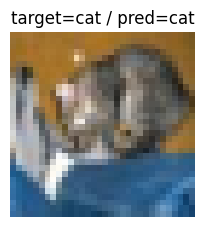

target label     : 3 cat
predicted label  : 3 cat
confidence       : 0.9999754428863525


In [4]:
with torch.no_grad():
    out = model(x)
    logits = out["preds"]
    prob = torch.softmax(logits, dim=1)[0].cpu()
    pred = int(prob.argmax())

plt.figure(figsize=(2.4, 2.4))
plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.title(f"target={classes[target]} / pred={classes[pred]}")
plt.show()

print("target label     :", target, classes[target])
print("predicted label  :", pred, classes[pred])
print("confidence       :", float(prob[pred]))

## **5. Reconstruction Error from `x_pub`**

- Feed `x_pub` to the pretrained reconstruction attacker.
- Compare the reconstructed image with the original image.
- Higher MSE means worse reconstruction.
- Lower PSNR means worse reconstruction.

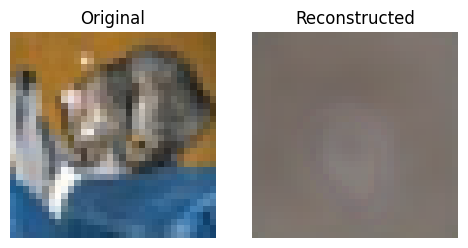

x_pub shape          : (1, 128, 16, 16)
reconstruction MSE   : 0.0356026217341423
reconstruction PSNR  : 14.485180377960205


In [5]:
with torch.no_grad():
    out = model(x)
    x_pub = out["x_pub"]
    x_recon = reconstructor(x_pub).clamp(0, 1)

mse = F.mse_loss(x_recon, x).item()
psnr = 10.0 * torch.log10(torch.tensor(1.0 / (mse + 1e-12))).item()

original = x[0].detach().cpu().clamp(0, 1)
reconstructed = x_recon[0].detach().cpu().clamp(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
axes[0].imshow(original.permute(1, 2, 0))
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(reconstructed.permute(1, 2, 0))
axes[1].set_title("Reconstructed")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print("x_pub shape          :", tuple(x_pub.shape))
print("reconstruction MSE   :", mse)
print("reconstruction PSNR  :", psnr)